<a href="https://colab.research.google.com/github/madhu-sudhana07/madhusudhana/blob/main/Business_Case_LoanTap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Business Case: LoanTap Logistic Regression**

LoanTap is an online platform committed to delivering customized loan products to millennials. They innovate in an otherwise dull loan segment, to deliver instant, flexible loans on consumer friendly terms to salaried professionals and businessmen.

The data science team at LoanTap is building an underwriting layer to determine the creditworthiness of MSMEs as well as individuals.

LoanTap deploys formal credit to salaried individuals and businesses 4 main financial instruments:

    Personal Loan
    EMI Free Loan
    Personal Overdraft
    Advance Salary Loan
This case study will focus on the underwriting process behind Personal Loan only

Problem Statement:

Given a set of attributes for an Individual, determine if a credit line should be extended to them. If so, what should the repayment terms be in business recommendations?

In [ ]:
# Data Manipulation and Analysis
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

# Modeling
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Load Dataset
df = pd.read_csv('/content/logistic_regression.csv')

# Display Basic Information
print(df.head())
print("No. of rows : ",df.shape[0])
print("No. of columns : ",df.shape[1])
print(df.info())
print(df.describe().round(2))


  loan_amnt        term  int_rate  installment grade sub_grade  \
0   10000.0   36 months     11.44       329.48     B        B4   
1    8000.0   36 months     11.99       265.68     B        B5   
2   15600.0   36 months     10.49       506.97     B        B3   
3    7200.0   36 months      6.49       220.65     A        A2   
4   24375.0   60 months     17.27       609.33     C        C5   

                 emp_title emp_length home_ownership  annual_inc  ...  \
0                Marketing  10+ years           RENT    117000.0  ...   
1          Credit analyst     4 years       MORTGAGE     65000.0  ...   
2             Statistician   < 1 year           RENT     43057.0  ...   
3          Client Advocate    6 years           RENT     54000.0  ...   
4  Destiny Management Inc.    9 years       MORTGAGE     55000.0  ...   

  open_acc pub_rec revol_bal revol_util total_acc  initial_list_status  \
0     16.0     0.0   36369.0       41.8      25.0                    w   
1     17.0     0

In [ ]:
#No. of unique values for each columns
print(df.nunique())

loan_amnt                 2563
term                         3
int_rate                   566
installment              55706
grade                        7
sub_grade                   35
emp_title               173105
emp_length                  11
home_ownership               6
annual_inc               27197
verification_status          3
issue_d                    115
loan_status                  2
purpose                     14
title                    48816
dti                       4262
earliest_cr_line           684
open_acc                    61
pub_rec                     20
revol_bal                55622
revol_util                1226
total_acc                  118
initial_list_status          2
application_type             3
mort_acc                    33
pub_rec_bankruptcies         9
address                 393701
dtype: int64


In [ ]:
print(df.isnull().sum())

loan_amnt                   0
term                        0
int_rate                    1
installment                 1
grade                       1
sub_grade                   1
emp_title               23163
emp_length              18498
home_ownership              1
annual_inc                  1
verification_status         1
issue_d                     1
loan_status                 1
purpose                     1
title                    1780
dti                         1
earliest_cr_line            1
open_acc                    1
pub_rec                     1
revol_bal                   1
revol_util                278
total_acc                   1
initial_list_status         1
application_type            1
mort_acc                38202
pub_rec_bankruptcies      540
address                     1
dtype: int64


In [ ]:
#Converting string to date-time format
df['issue_d']=pd.to_datetime(df['issue_d'])
df['earliest_cr_line']=pd.to_datetime(df['earliest_cr_line'])

In [ ]:
df['title']=df.title.str.lower()
df['title'].value_counts()[:10]

,count
title,
debt consolidation,169844
credit card refinancing,52323
home improvement,17297
other,13139
consolidation,5652
major purchase,5060
debt consolidation loan,3538
business,3050
medical expenses,2850


In [ ]:
#Need to fix the issue on title column
df['emp_title'].value_counts()[:10]

,count
emp_title,
Teacher,4432
Manager,4286
Registered Nurse,1875
RN,1865
Supervisor,1846
Sales,1659
Project Manager,1518
Owner,1424
Driver,1359


In [ ]:
# Extraction of pincode from the 'Address' column
df['pin_code'] = df['address'].str.split(' ').str[-1]
# Let's fetch ZIP from address and then drop the remaining details -
df['zip_code'] = df.address.apply(lambda x: x[-5:])

In [ ]:
#Convert columns with less number of unique values to categorical columns
cat_cols = ['term', 'grade','sub_grade','home_ownership',
            'verification_status','loan_status','purpose',
            'initial_list_status','application_type']

df[cat_cols] = df[cat_cols].astype('category')

In [ ]:
# Statistical summary of the dataset
print(df.describe().round(2))

       loan_amnt   int_rate  installment  annual_inc  \
count  396030.00  396030.00    396030.00   396030.00   
mean    14113.89      13.64       431.85    74203.18   
min       500.00       5.32        16.08        0.00   
25%      8000.00      10.49       250.33    45000.00   
50%     12000.00      13.33       375.43    64000.00   
75%     20000.00      16.49       567.30    90000.00   
max     40000.00      30.99      1533.81  8706582.00   
std      8357.44       4.47       250.73    61637.62   

                             issue_d        dti  \
count                         396030  396030.00   
mean   2014-02-02 15:57:58.045602560      17.38   
min              2007-06-01 00:00:00       0.00   
25%              2013-05-01 00:00:00      11.28   
50%              2014-04-01 00:00:00      16.91   
75%              2015-03-01 00:00:00      22.98   
max              2016-12-01 00:00:00    9999.00   
std                              NaN      18.02   

                    earliest_cr_lin

Nearly 80% of the loans have a term of 36 months.

The majority of loans (30%) are graded as B, followed by C, A, and D respectively.

For 50% of cases, the type of home ownership is mortgage.

The loan status target variable is biased towards fully-paid loans, with defaulters accounting for approximately 25% of fully-paid instances.

Approximately 85% of applicants do not have a public record or have not filed for bankruptcy.

Nearly all applicants (99%) have applied under the 'individual' application type. -The most common purpose for taking out loans is debt consolidation, accounting for 55%, followed by 20% for credit card purposes.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   loan_amnt             396030 non-null  float64       
 1   term                  396030 non-null  category      
 2   int_rate              396030 non-null  float64       
 3   installment           396030 non-null  float64       
 4   grade                 396030 non-null  category      
 5   sub_grade             396030 non-null  category      
 6   emp_title             373103 non-null  object        
 7   emp_length            377729 non-null  object        
 8   home_ownership        396030 non-null  category      
 9   annual_inc            396030 non-null  float64       
 10  verification_status   396030 non-null  category      
 11  issue_d               396030 non-null  datetime64[ns]
 12  loan_status           396030 non-null  category      
 13 

In [ ]:
# Checking the distribution of the outcome labels
df.loan_status.value_counts(normalize=True)*100

,proportion
loan_status,
Fully Paid,80.387092
Charged Off,19.612908


80% belongs to the class 0 : which is loan fully paid.
20% belongs to the class 1 : which were charged off.

In [ ]:
df.initial_list_status.value_counts(normalize=True)*100

,proportion
initial_list_status,
f,60.113123
w,39.886877


60% belongs to whole loans(w)
40% belongs to fractional loans(f)

In [ ]:
df.application_type.value_counts(normalize=True)*100

,proportion
application_type,
INDIVIDUAL,99.820468
JOINT,0.107315
DIRECT_PAY,0.072217


Maximum belongs to INDIVIDUAL application

In [ ]:
df.term.value_counts(normalize=True)*100

,proportion
term,
36 months,76.258112
60 months,23.741888


36-month loan terms apply to 76% of the loans, while 60-month loan terms apply to 24% of them.

In [ ]:
# The home ownership status provided by the borrower during registration or obtained from the credit report.
df.home_ownership.value_counts(normalize=True)*100

,proportion
home_ownership,
MORTGAGE,50.084085
RENT,40.347953
OWN,9.531096
OTHER,0.028281
NONE,0.007828
ANY,0.000758


50% loans belongs to mortgage
40% loans belongs to rent

In [ ]:
df.verification_status.value_counts(normalize=True)*100

,proportion
verification_status,
Verified,35.240512
Source Verified,33.175517
Not Verified,31.583971


In [ ]:
df.groupby(by = "loan_status")["loan_amnt"].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,77673.0,15126.300967,8505.090557,1000.0,8525.0,14000.0,20000.0,40000.0
Fully Paid,318357.0,13866.878771,8302.319699,500.0,7500.0,12000.0,19225.0,40000.0


<Axes: xlabel='loan_amnt', ylabel='loan_status'>

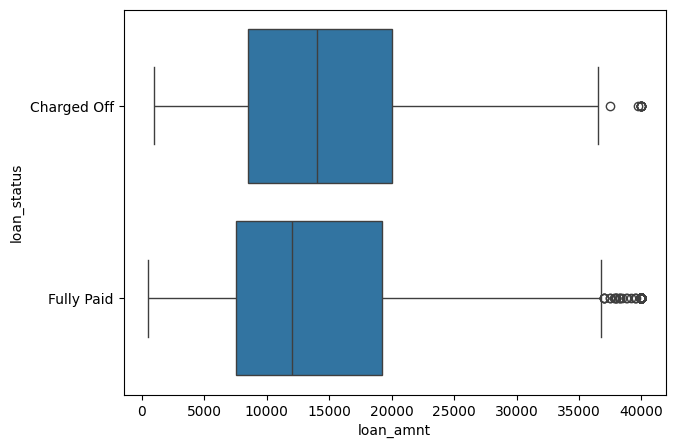

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df["loan_amnt"], y=df["loan_status"])

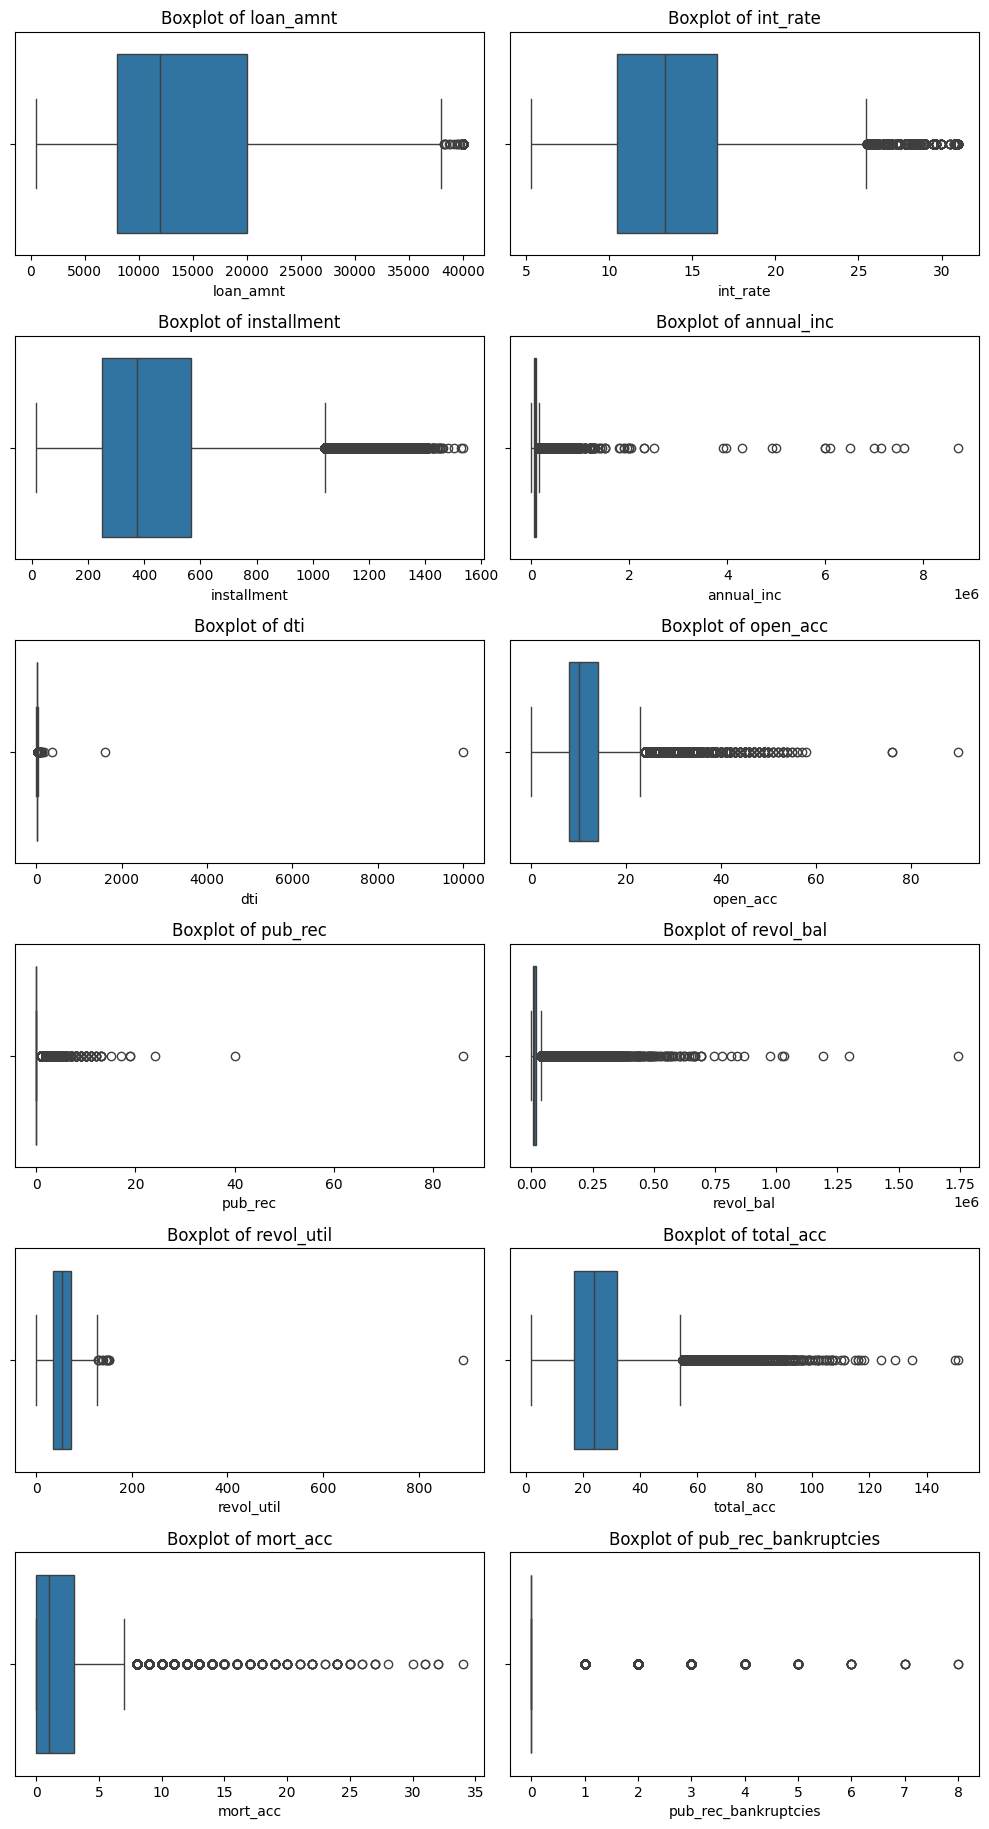

In [ ]:
num_cols = df.select_dtypes(include='number').columns

fig = plt.figure(figsize=(10,21))
i=1
for col in num_cols:
  ax = plt.subplot(7,2,i)
  sns.boxplot(x=df[col])
  plt.title(f'Boxplot of {col}')
  i += 1

plt.tight_layout()
plt.show()

<Axes: xlabel='loan_amnt', ylabel='Count'>

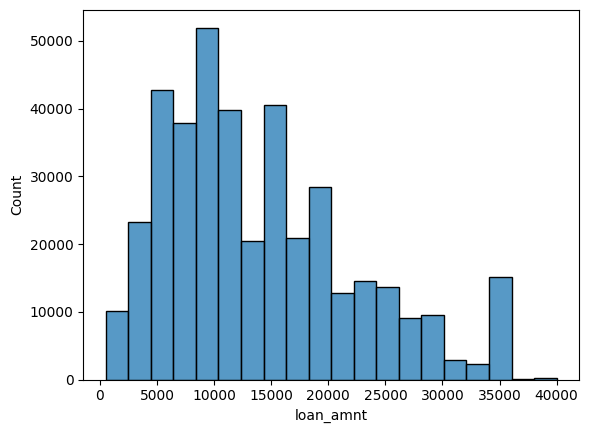

In [ ]:
sns.histplot(df["loan_amnt"],bins = 20)

for loan status Charged_off, the mean and median of loan_amount is higher than fully paid.
also the distribution of loan_amnt is right skewed, which says it has outlier presence.

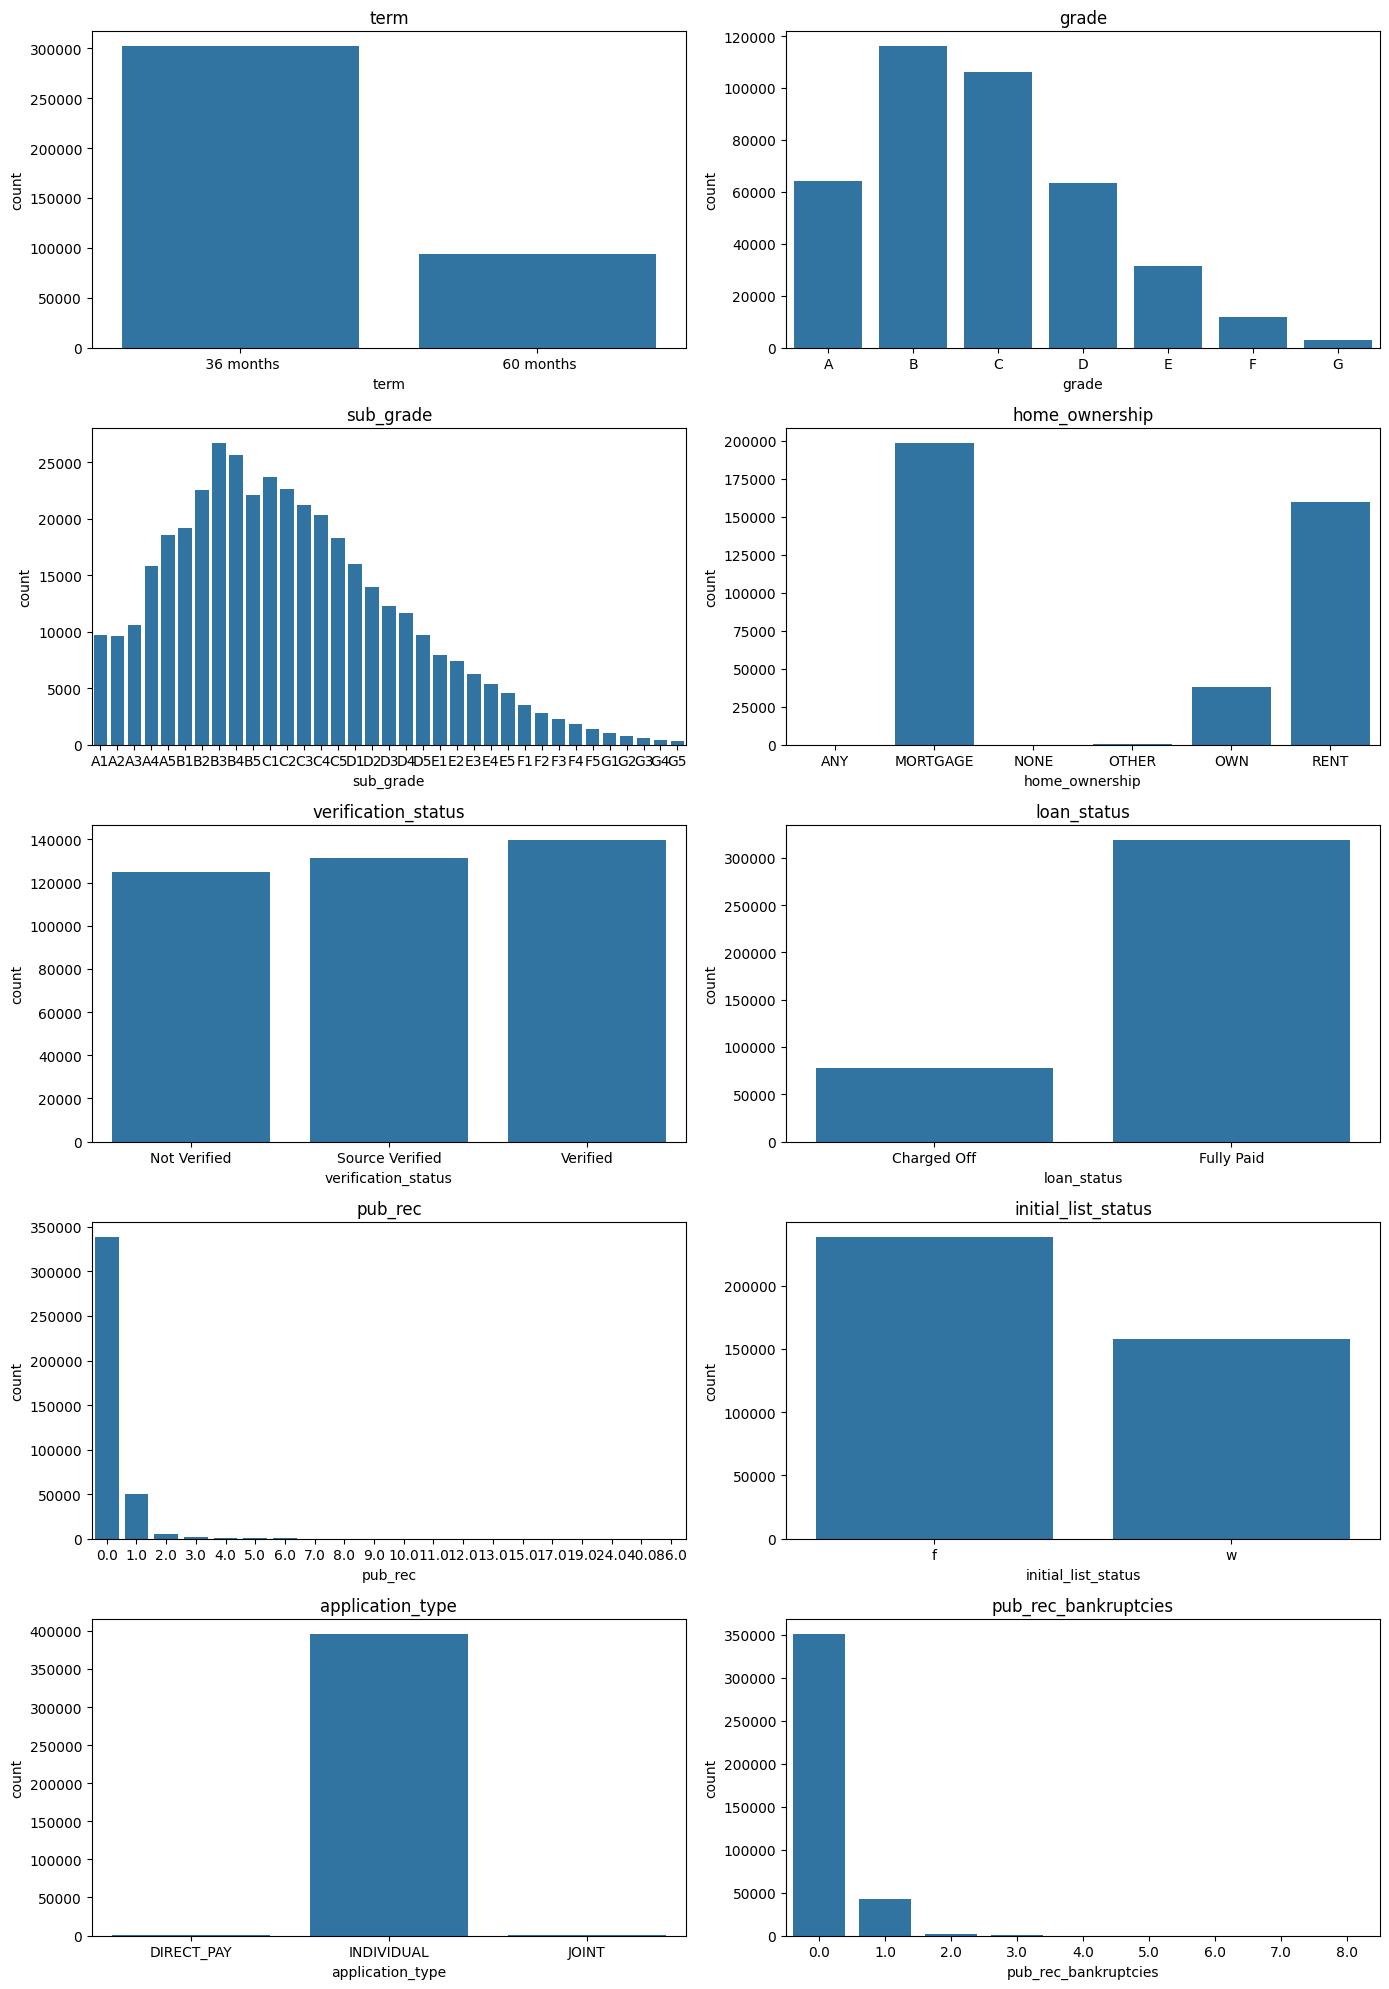

In [ ]:
#Distribution of categorical variables
plot = ['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status',
       'loan_status', 'pub_rec', 'initial_list_status',
       'application_type', 'pub_rec_bankruptcies']

plt.figure(figsize=(14,20))
i=1
for col in plot:
  ax=plt.subplot(5,2,i)
  sns.countplot(x=df[col])
  plt.title(f'{col}')
  i += 1

plt.tight_layout()
plt.show()

<Axes: xlabel='sub_grade'>

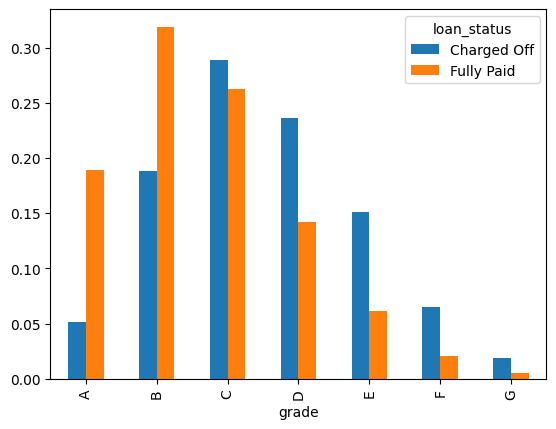

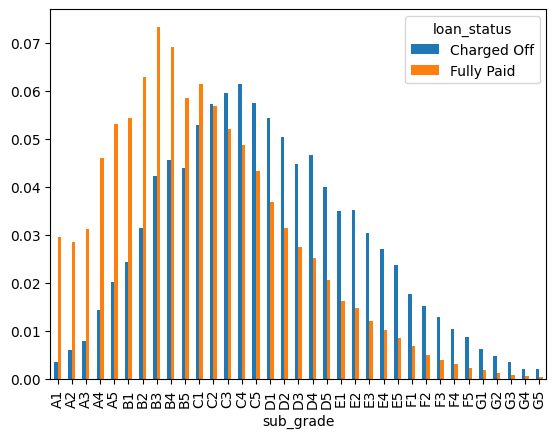

In [ ]:
pd.crosstab(index = df["grade"], columns= df["loan_status"],normalize= "columns").plot(kind  = "bar")

pd.crosstab(index = df["sub_grade"], columns= df["loan_status"],normalize= "columns", ).plot(kind = "bar")

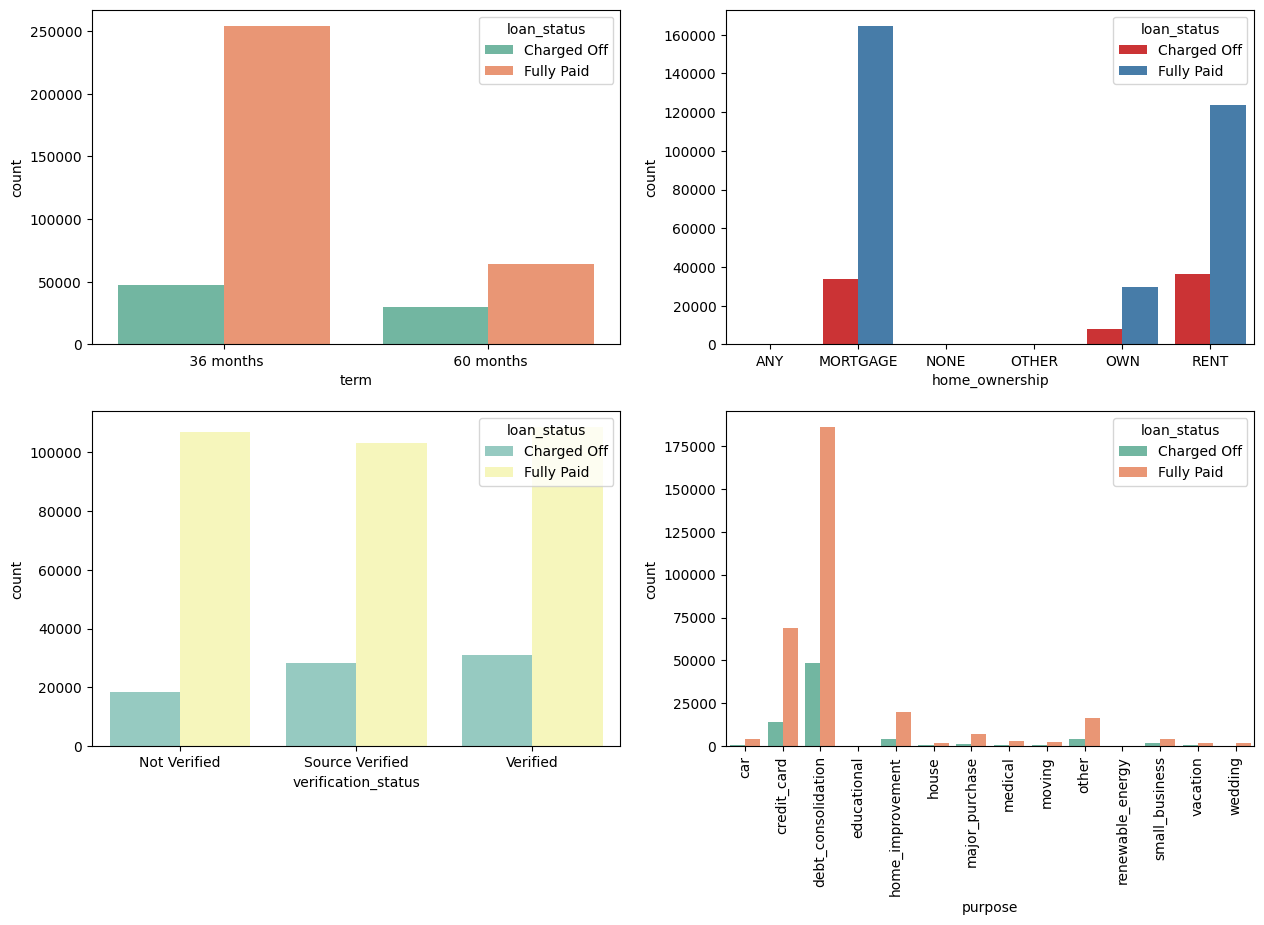

In [ ]:
plt.figure(figsize=(15,20))

plt.subplot(4,2,1)
sns.countplot(x='term',data=df,hue='loan_status', palette='Set2')

plt.subplot(4,2,2)
sns.countplot(x='home_ownership',data=df,hue='loan_status', palette='Set1')

plt.subplot(4,2,3)
sns.countplot(x='verification_status',data=df,hue='loan_status', palette='Set3')

plt.subplot(4,2,4)
g=sns.countplot(x='purpose',data=df,hue='loan_status', palette='Set2')
g.set_xticklabels(g.get_xticklabels(),rotation=90)
plt.show()

<Axes: xlabel='home_ownership'>

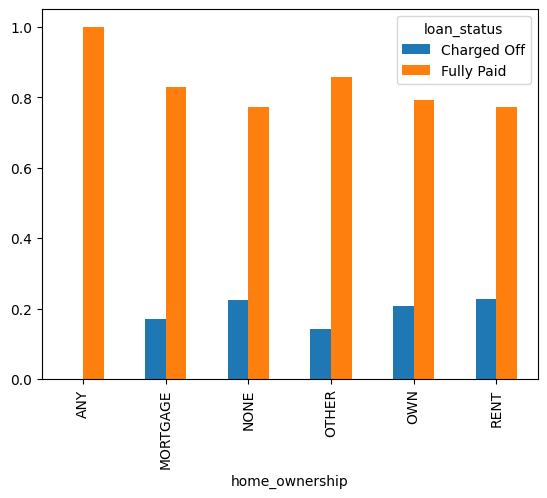

In [ ]:
pd.crosstab(index = df["home_ownership"], columns= df["loan_status"],normalize= "index").plot(kind= "bar")

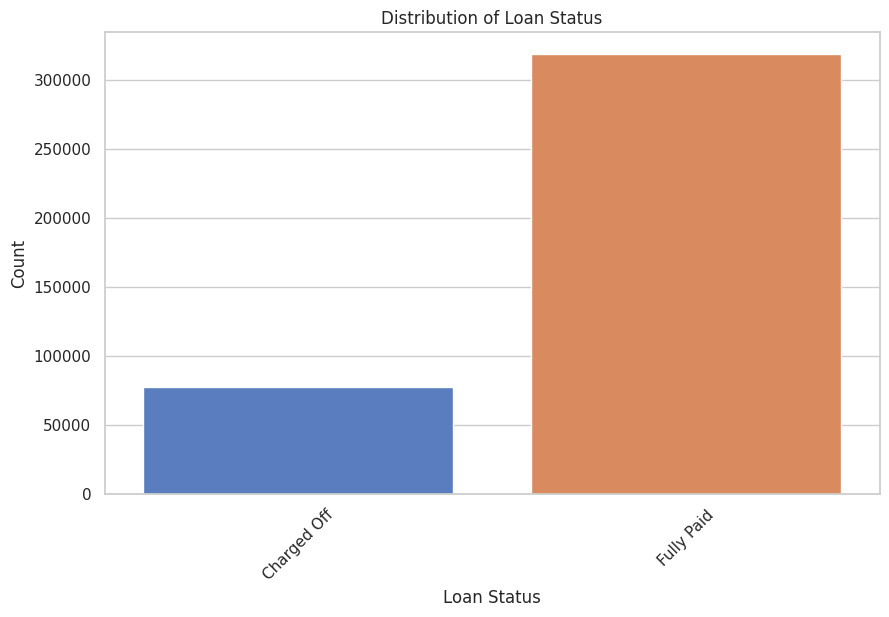

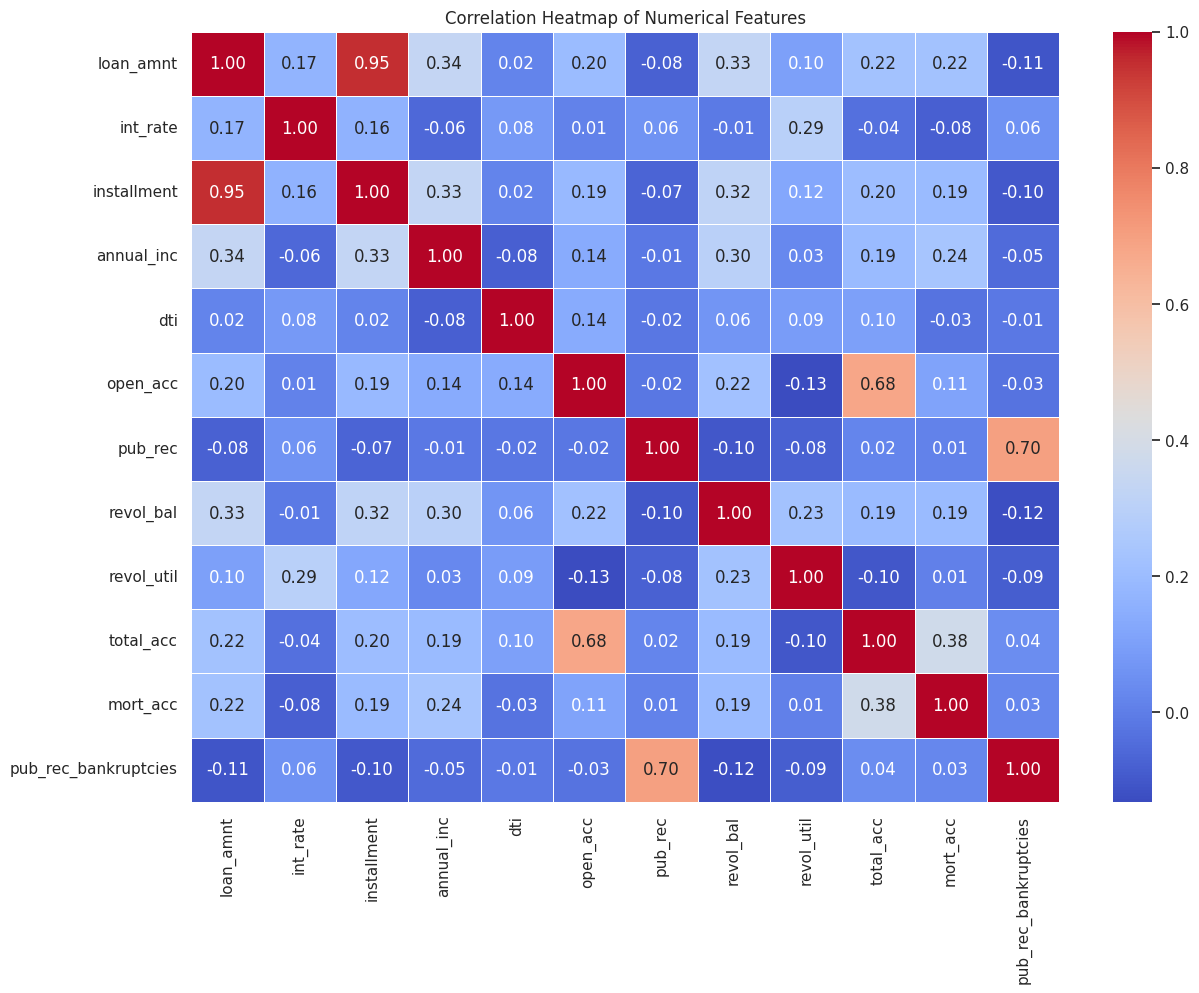

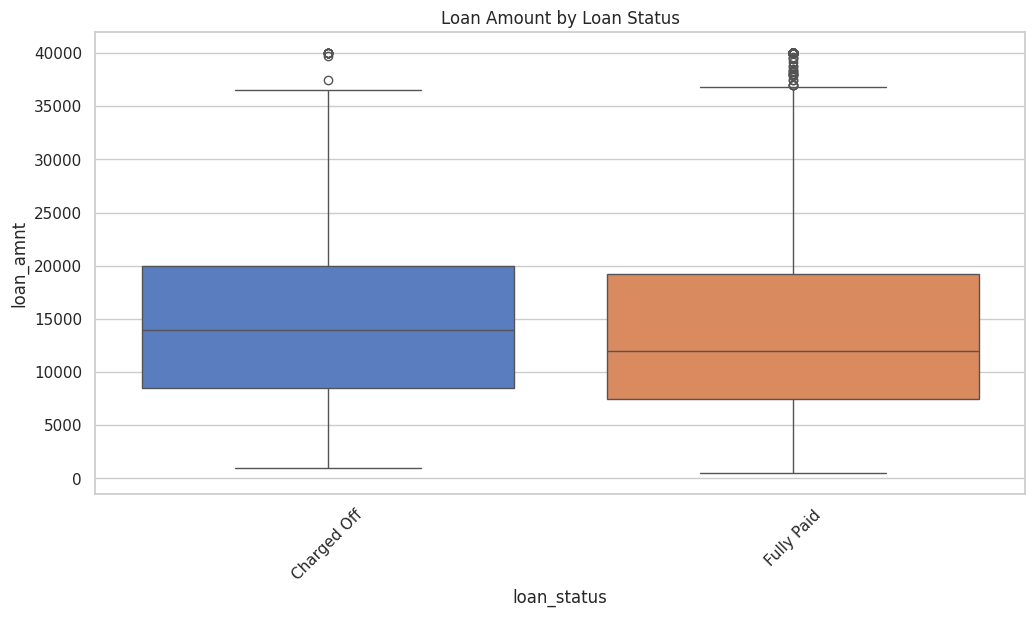

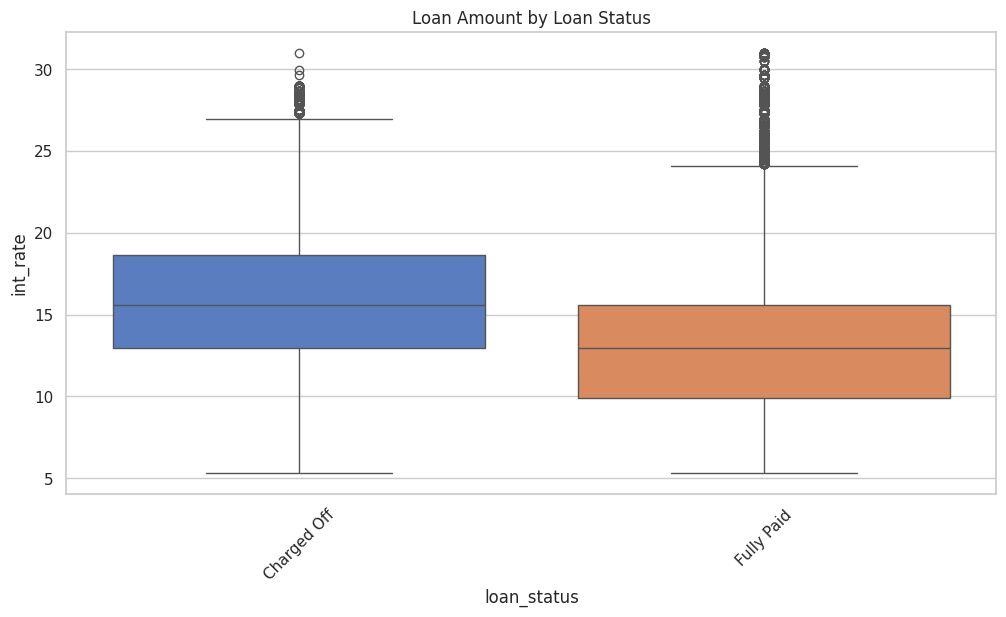

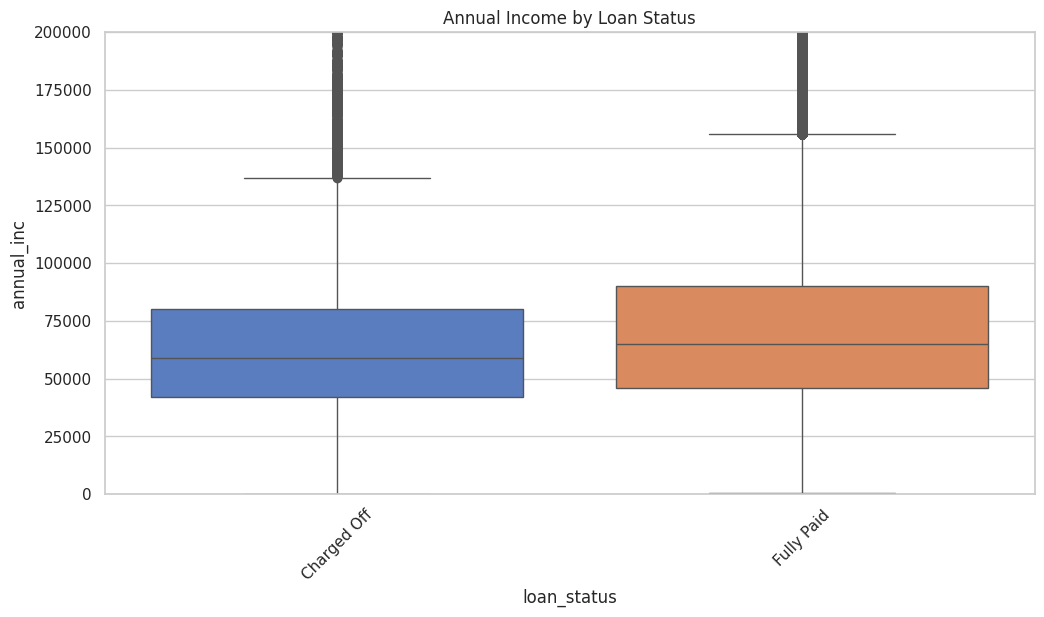

In [ ]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Set plot style
sns.set(style='whitegrid')

# Plot the distribution of the target variable 'loan_status'
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='loan_status', palette='muted')
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Correlation Heatmap for Numerical Features
plt.figure(figsize=(14, 10))
numerical_features = df.select_dtypes(include=['float64']).columns
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Boxplot for Loan Amount vs Loan Status
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='loan_status', y='loan_amnt', palette='muted')
plt.title('Loan Amount by Loan Status')
plt.xticks(rotation=45)
plt.show()

# Boxplot for Int rate vs Loan Status
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='loan_status', y='int_rate', palette='muted')
plt.title('Loan Amount by Loan Status')
plt.xticks(rotation=45)
plt.show()

# Boxplot for Annual Income vs Loan Status
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='loan_status', y='annual_inc', palette='muted')
plt.title('Annual Income by Loan Status')
plt.ylim(0, 200000)  # Limiting for better visualization
plt.xticks(rotation=45)
plt.show()


Data Preprocessing


In both the 'Categorical' and 'Numerical' categories, there are columns with a significant amount of missing data.
For the 'Numerical' data, these missing values will be filled with the mean, while for the 'Categorical' data, they will be filled with the mode.

In [ ]:
#Check for Duplicate Values
df.duplicated().sum()

0

In [ ]:
# Null values replaced by 'Mode' in case of 'Categorical' column.
column_mode = df['emp_length'].mode()[0]
df['emp_length'] = df['emp_length'].fillna(column_mode)

# Null values replaced by 'Mean' in case of 'Numerical' column.
for column in ['revol_util', 'mort_acc', 'pub_rec_bankruptcies']:
    column_mean = df[column].mean()
    df[column] = df[column].fillna(column_mean)

In [ ]:
df.isna().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
emp_title,22927
emp_length,0
home_ownership,0
annual_inc,0


In [ ]:
# Dropping some variables which we can let go for now
df.drop(columns=['issue_d', 'emp_title', 'title', 'sub_grade',
                   'address', 'earliest_cr_line', 'emp_length'],
                   axis=1, inplace=True)

Feature Engineering

In [ ]:
def  pub_rec(number):
    if number == 0:
        return 0
    else:
        return 1

def mort_acc(number):
    if number == 0.0:
        return 0
    elif number >= 1.0:
        return 1
    else:
        return number


def pub_rec_bankruptcies(number):
    if number == 0.0:
        return 0
    elif number >= 1.0:
        return 1
    else:
        return number

In [ ]:
df['pub_rec']=df.pub_rec.apply(pub_rec)
df['mort_acc']=df.mort_acc.apply(mort_acc)
df['pub_rec_bankruptcies']=df.pub_rec_bankruptcies.apply(pub_rec_bankruptcies)

<Axes: xlabel='pub_rec_bankruptcies', ylabel='count'>

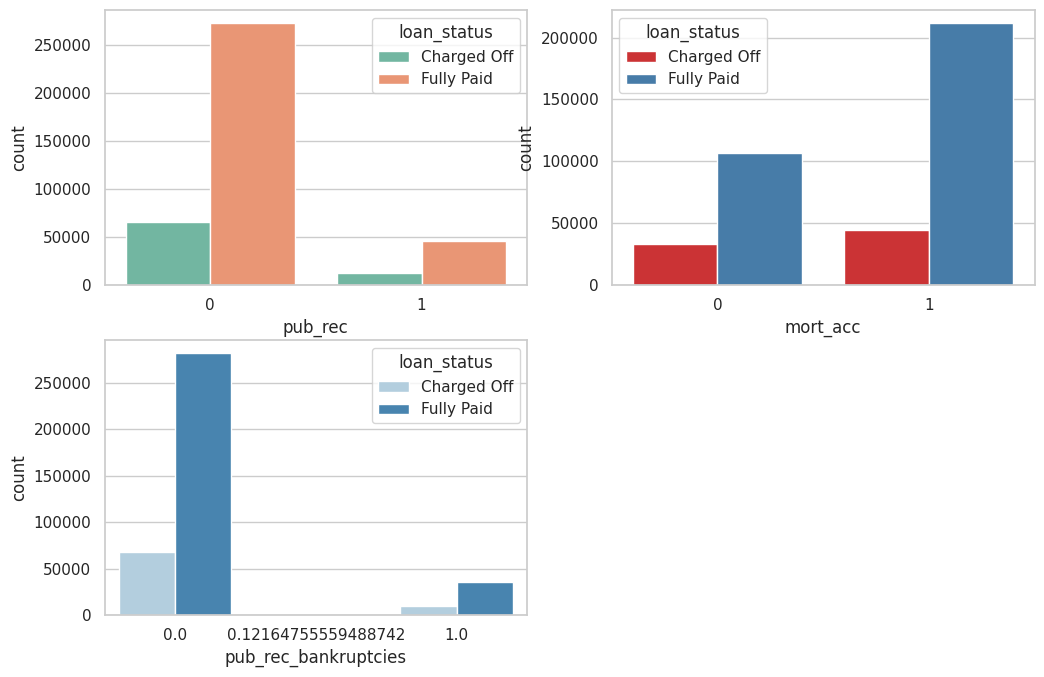

In [ ]:
plt.figure(figsize=(12,25))

plt.subplot(6,2,1)
sns.countplot(x='pub_rec',data=df,hue='loan_status', palette='Set2')

plt.subplot(6,2,2)
sns.countplot(x='mort_acc',data=df,hue='loan_status', palette='Set1')

plt.subplot(6,2,3)
sns.countplot(x='pub_rec_bankruptcies',data=df,hue='loan_status', palette='Blues')

In [ ]:
#pre processing
df['loan_status']=df.loan_status.map({'Fully Paid':0, 'Charged Off':1})

term_values={' 36 months': 36, ' 60 months':60}
df['term'] = df.term.map(term_values)

list_status = {'w': 0, 'f': 1}
df['initial_list_status'] = df.initial_list_status.map(list_status)

Outlier Detection & Treatment

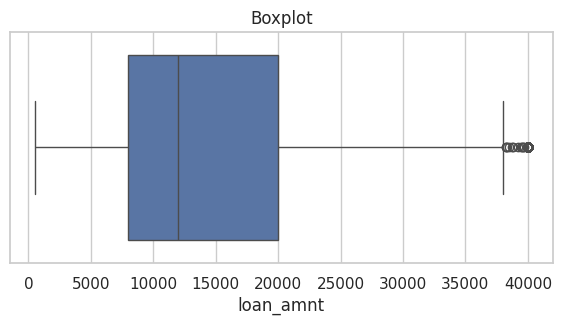

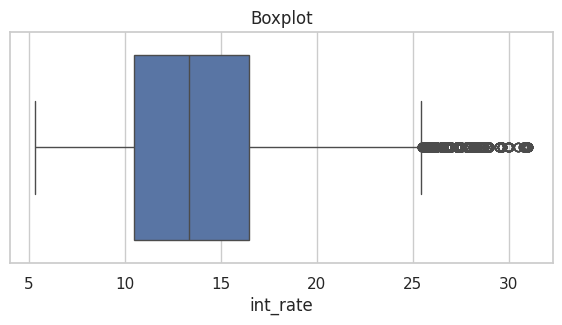

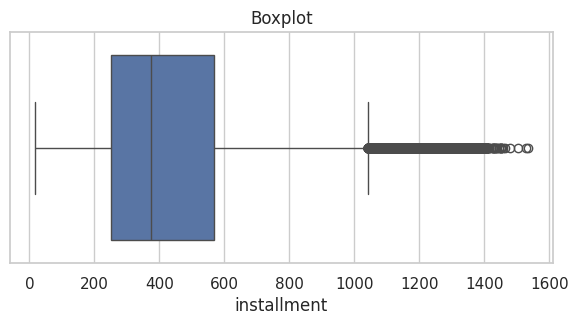

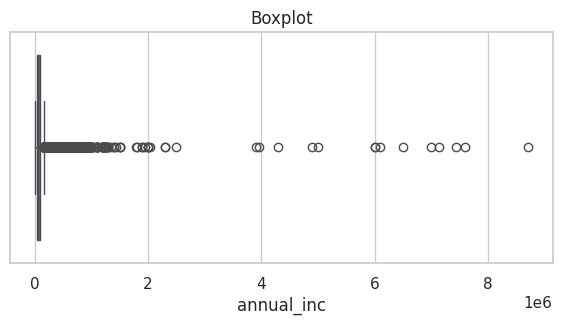

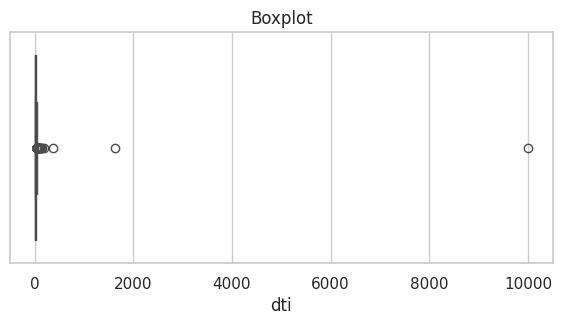

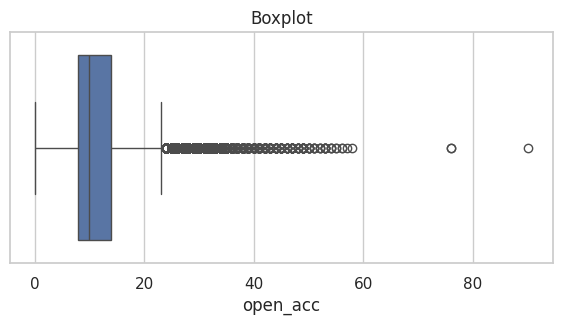

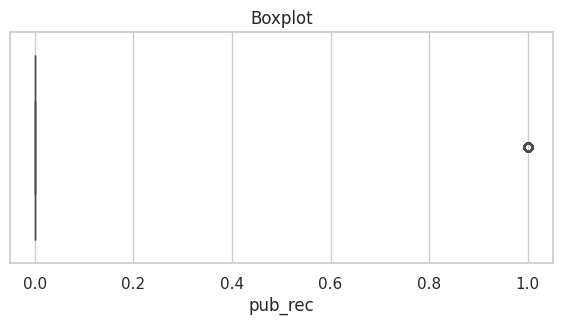

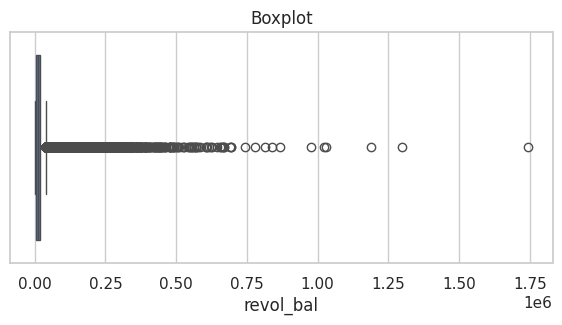

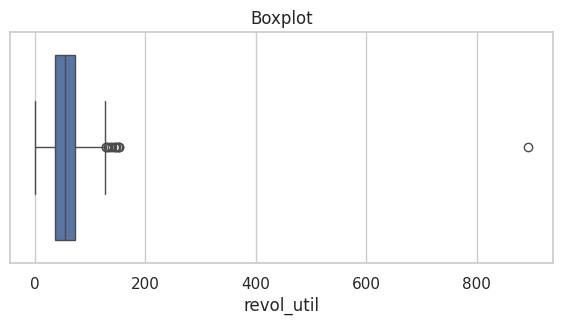

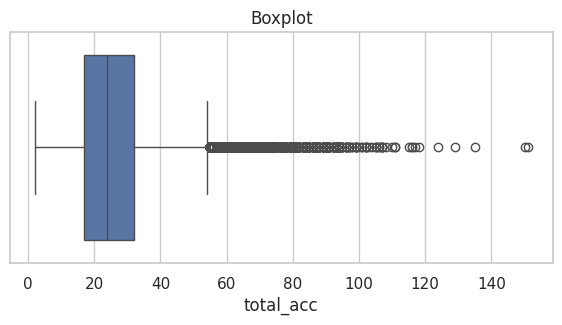

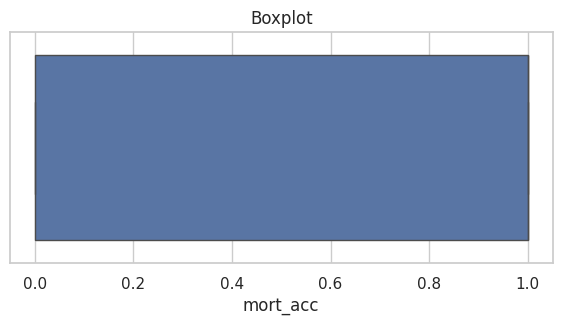

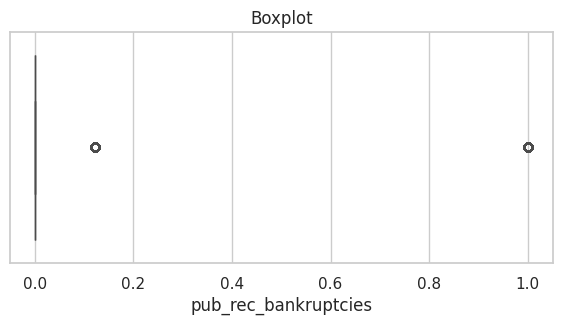

In [ ]:
numerical_col=df.select_dtypes(include='number')
num_cols=numerical_col.columns

def box_plot(col):
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.title('Boxplot')
    plt.show()

for col in num_cols:
    box_plot(col)

In [ ]:
for col in num_cols:
    mean=df[col].mean()
    std=df[col].std()

    upper_limit=mean+3*std
    lower_limit=mean-3*std

    df=df[(df[col]<upper_limit) & (df[col]>lower_limit)]

One Hot Encoding

In [ ]:
dummies=['purpose', 'zip_code', 'grade', 'verification_status', 'application_type', 'home_ownership']
df=pd.get_dummies(df,columns=dummies,drop_first=True)
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

df.head()


,loan_amnt,term,int_rate,installment,annual_inc,loan_status,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,mort_acc,pub_rec_bankruptcies,pin_code,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,zip_code_05113,zip_code_11650,zip_code_22690,zip_code_29597,zip_code_30723,zip_code_48052,zip_code_70466,zip_code_86630,zip_code_93700,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,verification_status_Source Verified,verification_status_Verified,application_type_INDIVIDUAL,application_type_JOINT,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT
0,10000.0,36,11.44,329.48,117000.0,0,26.24,16.0,0,36369.0,41.8,25.0,0,0,0.0,22690,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True
1,8000.0,36,11.99,265.68,65000.0,0,22.05,17.0,0,20131.0,53.3,27.0,1,1,0.0,05113,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False
2,15600.0,36,10.49,506.97,43057.0,0,12.79,13.0,0,11987.0,92.2,26.0,1,0,0.0,05113,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,True
3,7200.0,36,6.49,220.65,54000.0,0,2.60,6.0,0,5472.0,21.5,13.0,1,0,0.0,00813,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True
4,24375.0,60,17.27,609.33,55000.0,1,33.95,13.0,0,24584.0,69.8,43.0,1,1,0.0,11650,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,True,False,True,False,False,False,False


Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split
X=df.drop('loan_status',axis=1)
y=df['loan_status']
X_train , X_test , y_train , y_test = train_test_split(X,y,random_state=3,test_size=0.2)
print(X_train.shape)
print(X_test.shape)

(299649, 52)
(74913, 52)


MinMaxScaler

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [ ]:
X_train.head()

,loan_amnt,term,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,mort_acc,pub_rec_bankruptcies,pin_code,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,zip_code_05113,zip_code_11650,zip_code_22690,zip_code_29597,zip_code_30723,zip_code_48052,zip_code_70466,zip_code_86630,zip_code_93700,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,verification_status_Source Verified,verification_status_Verified,application_type_INDIVIDUAL,application_type_JOINT,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT
0,0.429230,0.0,0.518228,0.497159,0.233871,0.284874,0.461538,0.0,0.286772,0.577453,0.315789,0.0,0.0,0.0,0.508564,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.266623,0.0,0.461006,0.303769,0.229032,0.248459,0.346154,0.0,0.169182,0.765612,0.245614,1.0,0.0,0.0,0.749868,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.039500,0.0,0.359483,0.044141,0.125000,0.267927,0.269231,0.0,0.064800,0.529603,0.263158,1.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.232390,0.0,0.106138,0.235643,0.147056,0.263725,0.230769,0.0,0.242481,0.623682,0.315789,1.0,1.0,0.0,0.749868,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.131007,0.0,0.059991,0.130509,0.177419,0.135574,0.269231,0.0,0.081237,0.224655,0.263158,1.0,1.0,0.0,0.309882,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


Oversampling with SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE
sm=SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train,y_train.ravel())

print(f"Before OverSampling, count of label 1: {sum(y_train == 1)}")
print(f"Before OverSampling, count of label 0: {sum(y_train == 0)}")
print(f"After OverSampling, count of label 1: {sum(y_train_res == 1)}")
print(f"After OverSampling, count of label 0: {sum(y_train_res == 0)}")

Before OverSampling, count of label 1: 58851
Before OverSampling, count of label 0: 240798
After OverSampling, count of label 1: 240798
After OverSampling, count of label 0: 240798


Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_res, y_train_res)
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

In [ ]:
from sklearn.metrics import (accuracy_score, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay,
                             f1_score, recall_score,
                             precision_score, precision_recall_curve,
                             average_precision_score, classification_report)

#Model Evaluation
print('Train Accuracy :', model.score(X_train, y_train))
print('Train F1 Score:',f1_score(y_train,train_preds))
print('Train Recall Score:',recall_score(y_train,train_preds))
print('Train Precision Score:',precision_score(y_train,train_preds))

print('\nTest Accuracy :',model.score(X_test,y_test))
print('Test F1 Score:',f1_score(y_test,test_preds))
print('Test Recall Score:',recall_score(y_test,test_preds))
print('Test Precision Score:',precision_score(y_test,test_preds))

Train Accuracy : 0.7978067672510171
Train F1 Score: 0.6111506889757462
Train Recall Score: 0.8090261847717116
Train Precision Score: 0.4910478547854785

Test Accuracy : 0.8009023800942426
Test F1 Score: 0.6135309512087684
Test Recall Score: 0.8096149900841141
Test Precision Score: 0.4939090529828953


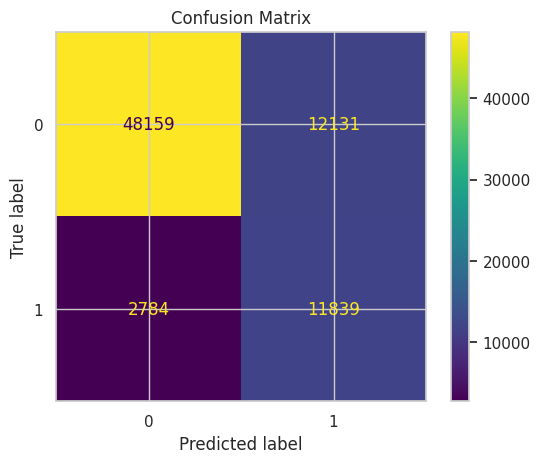

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

Classification Report

In [ ]:
print(classification_report(y_test, test_preds))

              precision    recall  f1-score   support

           0       0.95      0.80      0.87     60290
           1       0.49      0.81      0.61     14623

    accuracy                           0.80     74913
   macro avg       0.72      0.80      0.74     74913
weighted avg       0.86      0.80      0.82     74913



We notice that the recall score is notably high, indicating our model can identify 80% of actual defaulters. However, the precision for the positive class is low; only 50% of the predicted defaulters are actual defaulters.

While this model effectively identifies a significant portion of defaulters, it risks denying loans to deserving customers due to the high rate of false positives.

Furthermore, the low precision contributes to a decrease in the F1 score to 60%, despite the accuracy being 80%.

Feature Importance

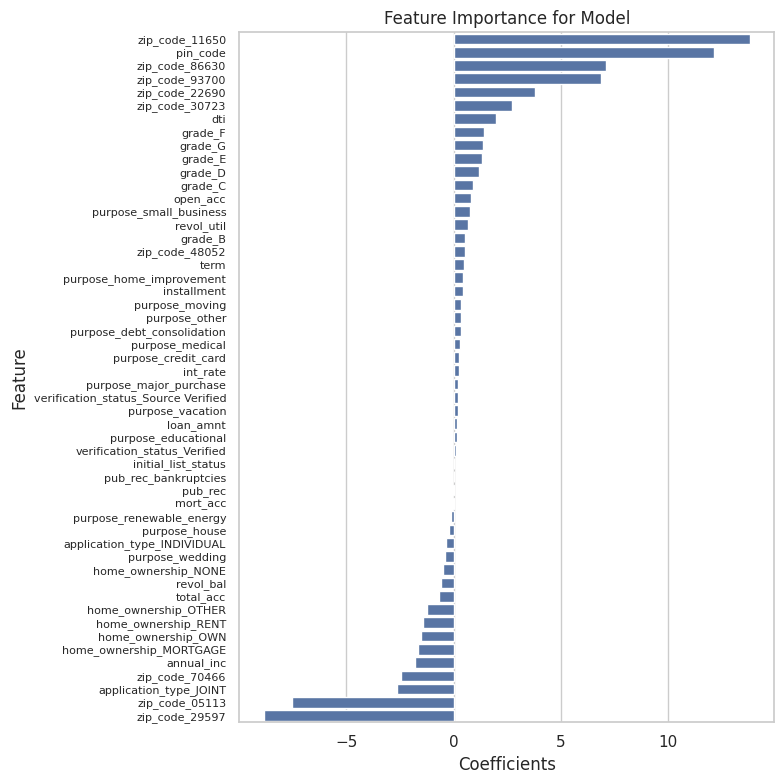

In [ ]:
feature_imp = pd.DataFrame({'Columns':X_train.columns,
                            'Coefficients':model.coef_[0]}).round(2).sort_values('Coefficients', ascending=False)

plt.figure(figsize=(8,8))
sns.barplot(y = feature_imp['Columns'],
           x =  feature_imp['Coefficients'])
plt.title("Feature Importance for Model")
plt.yticks(fontsize=8)
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

ROC Curve & AUC

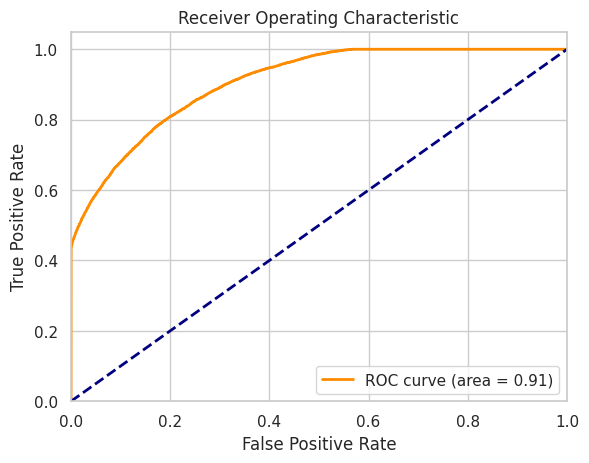

In [ ]:
# Predict probabilities for the test set
probs = model.predict_proba(X_test)[:,1]

# Compute the false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, probs)

# Compute the area under the ROC curve
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


An AUC of 0.91 indicates that the model effectively distinguishes between the positive and negative classes.

However, it's not an ideal metric for imbalanced target variables since it can be high even when the classifier performs poorly on the minority class.

This discrepancy occurs when the classifier excels at classifying instances from the majority class, which are more prevalent in the dataset. Consequently, the AUC might appear high, masking the model's inability to accurately identify instances from the minority class.

Precision Recall Curve

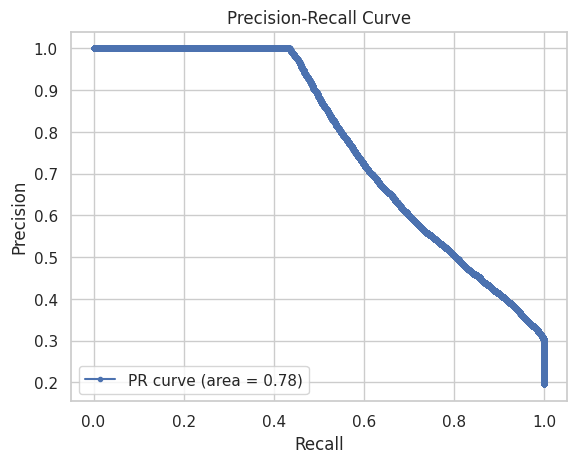

In [ ]:
precision, recall, thr = precision_recall_curve(y_test, probs)

# Area under Precision Recall Curve
apc = average_precision_score(y_test, probs)

# Plot the precision-recall curve
plt.plot(recall, precision, marker='.', label='PR curve (area = %0.2f)' % apc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

The area under the precision-recall curve (AUC-PR) is not as high as desired. While it exceeds the benchmark of 0.5 for a random model, indicating some level of effectiveness.

**Tradeoff Questions:**

Q1. How can we make sure that our model can detect real defaulters and there are less false positives? This is important as we can lose out on an opportunity to finance more individuals and earn interest on it.

Ans: The precision score serves as an indicator of Type I error. By increasing the precision score of the model, we can minimize false positives. This ensures that the company avoids erroneously denying loans to deserving individuals, thus maximizing the opportunity to finance worthy applicants.

Q2. Since NPA (non-performing asset) is a real problem in this industry, it’s important we play safe and shouldn’t disburse loans to anyone.

Ans: The recall score serves as an indicator of how effectively the model identifies actual defaulters. By increasing the recall score, we can minimize false negatives (Type II error), thereby ensuring that loans are not disbursed to defaulters, thus enhancing the model's ability to identify risky applicants.

**Questionnaire**

1. What percentage of customers have fully paid their Loan Amount?

    80% belongs to the class 0 : which is loan fully paid.

    20% belongs to the class 1 : which were charged off.

2. Comment about the correlation between Loan Amount and Installment features.

    Loan amount has a positive correlation with Installment features.

3. The majority of people have home ownership as MORTGAGE.

4. People with grades ‘A’ are more likely to fully pay their loan. (T/F)- True

5. Name the top 2 afforded job titles.
    Teacher, Manager

6. Thinking from a bank's perspective, which metric should our primary focus be on-
    For Fraud Detection: Prioritize Recall.
    For Loan Approvals: Prioritize Precision.
    For Credit Risk Assessment: Optimize the F1-Score.

7. How does the gap in precision and recall affect the bank?

    Fraud Detection:

    High recall reduces missed fraud cases, which is positive.

    Low precision means many legitimate transactions are flagged as fraud, increasing customer frustration and operational overhead.

    Loan Approvals:

    High recall ensures most risky applicants are detected.

    Low precision means many potentially good applicants may be denied, impacting revenue and customer relationships.

8. Which were the features that heavily affected the outcome?
    Zip codes such as 11650, 86630 and 93700

9. Will the results be affected by geographical location?
    Yes

**Insights**

Loan Amount distribution / media is slightly higher for Charged_off loanStatus.

the probability of defaulters is higher in the small_business owner borrowers.

Total credit revolving balance is almost same for both borrowers who had fully paid loan and declared defaulter

Probability of CHarged_off status is higher in case of 60 month term.

Zip codes such as 11650, 86630 and 93700 have 100% defaulters

It can be observed that the mean loan_amnt, int_rate, dti, open_acc and revol_util are higher for defaulters.

The % of defaulters is much higher for longer (60-month) term.

A Logistic Regression model performed well, rendering accuracy of 80%.

We can remove initial_list_status and state as they have no impact on loan_status

The model had a precision score of 95%, recall score of 80%, and f1 score of 87% on the negative class.

The model had a precision score of 49%, recall score of 81%, and f1 score of 61% on the positive class.

The features "grade" and "sub-grade" have the most significant impact on the loan_status, with higher grades typically associated with a higher likelihood of default. In particular, loans assigned the highest grade tend to have the highest proportion of defaulters.

**Recommendations**

Since NPA is a real problem in the industry , Company should more investigate and check for the proof of assets. Since it was observed in probability plot, verified borrowers had higher probability of defaulters than non-varified.

Prioritize 'A' grade applicants and shorter-term loans for lower default risk.

Balancing risk of increasing NPAs by disbursing loans to defaulters with the opportunity to earn interest by disbursing loans to as many worthy customers as possible is to maximize the F1 score along with the area under the Precision-Recall Curve.